## Custom Least Squares Function

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def least_squares_custom(X, Y):
    x_mean = np.mean(X)
    y_mean = np.mean(Y)

    m = np.sum((X - x_mean) * (Y - y_mean)) / np.sum((X - x_mean) ** 2)
    b = y_mean - m * x_mean

    return m, b

## Random Equation

In [10]:
X_random = np.random.rand(20)
Y_random = np.random.rand(20)
X_random = np.sort(X_random)

m_random_custom, b_random_custom = least_squares_custom(X_random, Y_random)

A_random = np.vstack([X_random, np.ones(len(X_random))]).T
m_random_np, c_random_np = np.linalg.lstsq(A_random, Y_random, rcond=None)[0]


X = np.arange(0, 1.01, 0.01)

true_m = np.random.uniform(-10, 10)
true_b = np.random.uniform(-5, 5)
noise = np.random.uniform(-1, 1, len(X))

Y = true_m * X + true_b + noise


m_custom, b_custom = least_squares_custom(X, Y)

## Given Code

In [12]:
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]


Y_pred = m_custom * X + b_custom
residuals = Y - Y_pred

largest = np.argmax(np.abs(residuals))
smallest = np.argmin(np.abs(residuals))

## Print Values

In [13]:
print("Random vector test")
print("Custom slope:", m_random_custom, "Intercept:", b_random_custom)
print("NumPy slope:", m_random_np, "Intercept:", c_random_np)
print()

print("Original equation")
print("Slope:", true_m, "Intercept:", true_b)
print()

print("Custom Least Squares")
print("Slope:", m_custom, "Intercept:", b_custom)
print()

print("NumPy Least Squares")
print("Slope:", m, "Intercept:", c)
print()

print("Residuals:")
print(residuals)
print()

print("Largest residual:", residuals[largest], "at point", (X[largest], Y[largest]))
print("Smallest residual:", residuals[smallest], "at point", (X[smallest], Y[smallest]))

Random vector test
Custom slope: 0.25500803871526273 Intercept: 0.2973041854133338
NumPy slope: 0.25500803871526284 Intercept: 0.29730418541333375

Original equation
Slope: 4.036718003372581 Intercept: 1.9729765601908404

Custom Least Squares
Slope: 3.5617492442811827 Intercept: 2.139028062794268

NumPy Least Squares
Slope: 3.5617492442811822 Intercept: 2.139028062794268

Residuals:
[-1.21818960e-01  7.14970471e-01 -6.71275771e-01 -3.54586214e-02
  2.81784142e-02  6.81527166e-02  1.80209008e-01 -9.69191540e-01
 -2.36620172e-01 -1.24848738e-01 -6.67495033e-01 -4.97470716e-01
  2.41220389e-01 -9.85966932e-01 -4.32012140e-01 -1.92797233e-01
  7.77521852e-01  4.41114196e-01  8.43147589e-01 -5.68298683e-01
  8.17315583e-01 -1.30038272e-01 -3.19883691e-01  7.21299481e-01
  3.36917786e-01 -6.65639012e-01 -1.92507625e-01  3.30657626e-01
  8.81794802e-01 -4.06156988e-01 -7.04776408e-01 -3.02234774e-01
  3.85215082e-01 -2.62079770e-01 -4.61325310e-01 -5.35925888e-01
  5.94192005e-01 -6.32495626e

## Plot

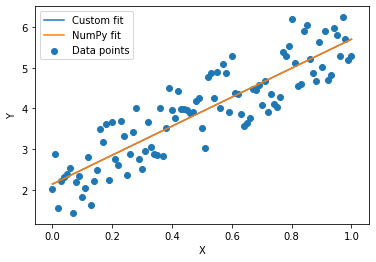

In [14]:
plt.scatter(X, Y, label="Data points")
plt.plot(X, m_custom * X + b_custom, label="Custom fit")
plt.plot(X, m * X + c, label="NumPy fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()